#### Spam ham dat set Import

In [9]:
import pandas as pd
import re, kagglehub, os
from sklearn.preprocessing import LabelEncoder

path = kagglehub.dataset_download('uciml/sms-spam-collection-dataset')
df = pd.read_csv(os.path.join(path, 'spam.csv'), encoding='latin-1')[['v1', 'v2']]
df.columns = ['label', 'message']
df['label_encoded'] = LabelEncoder().fit_transform(df['label'])
print(df.shape)
df.head()

(5572, 3)


,label,message,label_encoded
0,ham,"Go until jurong point, crazy.. Available only ...",0
1,ham,Ok lar... Joking wif u oni...,0
2,spam,Free entry in 2 a wkly comp to win FA Cup fina...,1
3,ham,U dun say so early hor... U c already then say...,0
4,ham,"Nah I don't think he goes to usf, he lives aro...",0


### EDA

In [11]:
counts = df.groupby("label").size().reset_index(name="Count")
print(counts)


  label  Count
0   ham   4825
1  spam    747


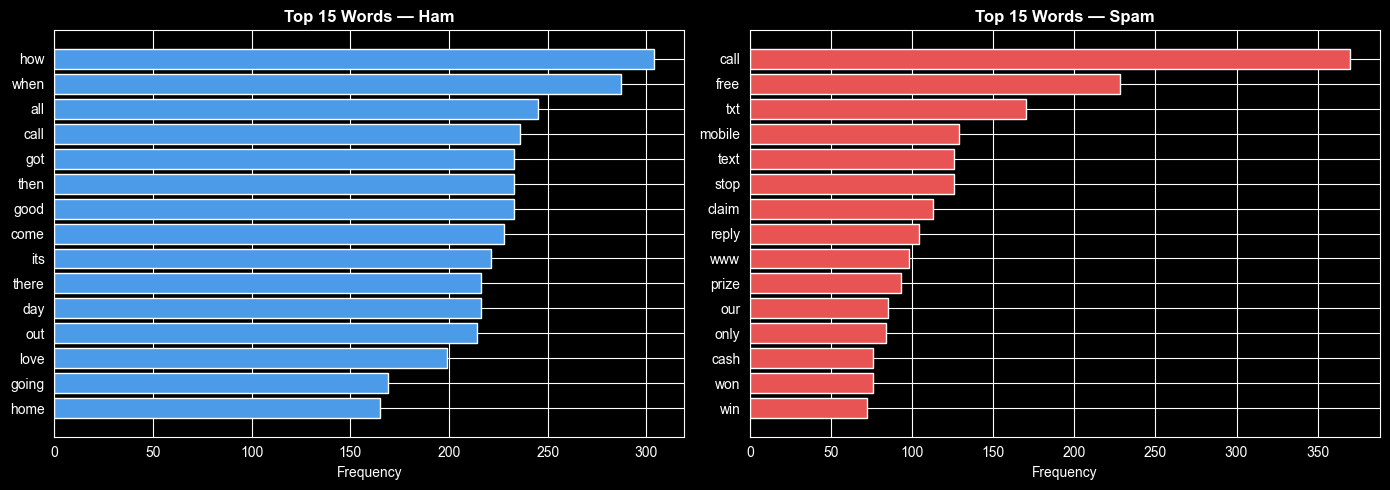

In [10]:
from collections import Counter
import matplotlib.pyplot as plt

STOPWORDS = {'the','a','an','to','of','and','in','is','it','you','i','for','me','my',
             'your','we','that','on','at','are','this','have','with','not','was','be',
             'but','they','or','so','do','if','he','she','no','now','just','up','get',
             'can','will','one','go','about','what','time','know','like','from',
             'u','ur','2','4','da','r','amp'}

def top_words(series, n=15):
    words = re.sub(r'[^a-z ]', ' ', ' '.join(series).lower()).split()
    return Counter([w for w in words if w not in STOPWORDS and len(w) > 2]).most_common(n)

fig, axes = plt.subplots(1, 2, figsize=(14, 5))
for ax, label, color, title in [
    (axes[0], 'ham',  '#4C9BE8', 'Top 15 Words — Ham'),
    (axes[1], 'spam', '#E85454', 'Top 15 Words — Spam')
]:
    words, freqs = zip(*top_words(df[df['label']==label]['message']))
    ax.barh(words[::-1], freqs[::-1], color=color, edgecolor='white')
    ax.set_title(title, fontweight='bold')
    ax.set_xlabel('Frequency')
plt.tight_layout()
plt.show()

### Feature extraction

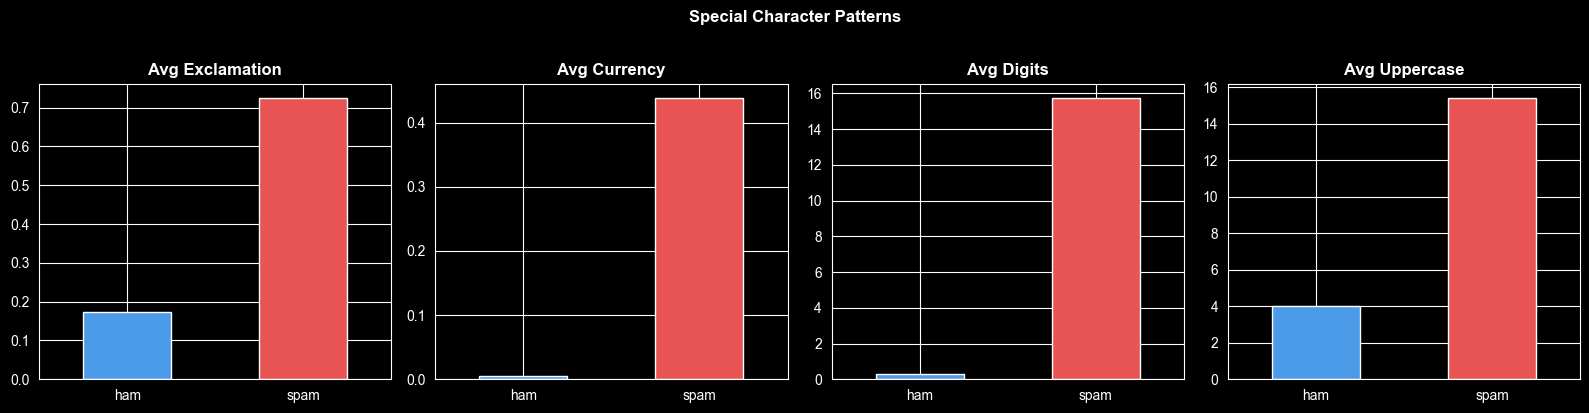

       char_count  word_count  exclamation  currency  digits  uppercase
label                                                                  
ham         71.02       14.20         0.17      0.00    0.30       4.04
spam       138.87       23.85         0.73      0.44   15.76      15.44


In [43]:
df['char_count'] = df['message'].apply(lambda x: len(x))
df['word_count'] = df['message'].apply(lambda x: len(x.split()))
df['exclamation'] = df['message'].apply(lambda x: x.count('!'))
df['currency']    = df['message'].apply(lambda x: x.count('$') + x.count('£'))
df['digits']      = df['message'].apply(lambda x: sum(c.isdigit() for c in x))
df['uppercase']   = df['message'].apply(lambda x: sum(c.isupper() for c in x))

EDA_FEATURES = ['char_count', 'word_count', 'exclamation', 'currency', 'digits', 'uppercase']

fig, axes = plt.subplots(1, 4, figsize=(16, 4))
for ax, feat in zip(axes, ['exclamation', 'currency', 'digits', 'uppercase']):
    df.groupby('label')[feat].mean().plot(kind='bar', ax=ax,
        color=['#4C9BE8', '#E85454'], edgecolor='white', rot=0)
    ax.set_title(f'Avg {feat.capitalize()}', fontweight='bold')
    ax.set_xlabel('')
plt.suptitle('Special Character Patterns', fontweight='bold', y=1.02)
plt.tight_layout()
plt.show()
print(df.groupby('label')[EDA_FEATURES].mean().round(2))

### Pre Processing
   EDA features are scaled with MinMaxScaler and stacked onto TF-IDF. max_features=1000 was selected by testing 500–10000 against SVM F1 score.

In [44]:
from scipy.sparse import hstack, csr_matrix
from sklearn.preprocessing import MinMaxScaler
from sklearn.model_selection import train_test_split
from sklearn.feature_extraction.text import TfidfVectorizer

df_train, df_test = train_test_split(df, test_size=0.2, random_state=42, stratify=df['label_encoded'])
tfidf  = TfidfVectorizer(max_features=1000, stop_words='english')
scaler = MinMaxScaler()

X_tfidf_train = tfidf.fit_transform(df_train['message'])
X_tfidf_test  = tfidf.transform(df_test['message'])

X_extra_train = scaler.fit_transform(df_train[EDA_FEATURES])
X_extra_test  = scaler.transform(df_test[EDA_FEATURES])

X_train = hstack([X_tfidf_train, csr_matrix(X_extra_train)])
X_test  = hstack([X_tfidf_test,  csr_matrix(X_extra_test)])
y_train =  df_train['label_encoded'].values
y_test  = df_test['label_encoded'].values
print(f'Train: {X_train.shape} | Test: {X_test.shape} | Features: {X_train.shape}')

Train: (4457, 1006) | Test: (1115, 1006) | Features: (4457, 1006)


In [45]:
from sklearn.svm import LinearSVC
from sklearn.metrics import f1_score
for n in [500, 1000, 2000, 5000, 7500, 10000]:
    vec = TfidfVectorizer(max_features=n, stop_words='english')
    clf = LinearSVC(max_iter=2000)
    clf.fit(vec.fit_transform(df_train['message']), y_train)
    score = f1_score(y_test, clf.predict(vec.transform(df_test['message'])))
    print(f'max_features={n:<6}  F1: {score*100:.2f}%')

max_features=500     F1: 92.63%
max_features=1000    F1: 94.41%
max_features=2000    F1: 92.91%
max_features=5000    F1: 93.99%
max_features=7500    F1: 93.62%
max_features=10000   F1: 93.62%


Start training and evaluation

In [30]:
from sklearn.metrics import accuracy_score, precision_score, recall_score, f1_score, classification_report
from sklearn.neural_network import MLPClassifier
from sklearn.neighbors import KNeighborsClassifier
from sklearn.linear_model import LogisticRegression
from sklearn.svm import LinearSVC
from sklearn.naive_bayes import MultinomialNB
from sklearn.metrics import roc_curve, auc

MODELS = {
    'Naive Bayes':         MultinomialNB(),
    'SVM':                 LinearSVC(max_iter=2000, C=1.0),
    'Logistic Regression': LogisticRegression(max_iter=1000, random_state=42),
    'KNN (k=5)':           KNeighborsClassifier(n_neighbors=5, metric='cosine'),
    'Neural Network':      MLPClassifier(hidden_layer_sizes=(128, 64), max_iter=200,
                                         random_state=42, early_stopping=True),
}

results, all_preds = {}, {}

def evaluate(name, model):
    model.fit(X_train, y_train)
    pred = model.predict(X_test)
    all_preds[name] = pred
    fpr, tpr, _ = roc_curve(y_test, pred)
    roc_auc = auc(fpr, tpr)

    results[name] = {
        'Accuracy':  round(accuracy_score(y_test, pred)*100, 2),
        'Precision': round(precision_score(y_test, pred)*100, 2),
        'Recall':    round(recall_score(y_test, pred)*100, 2),
        'F1 Score':  round(f1_score(y_test, pred)*100, 2),
        'fpr': fpr,
        'tpr': tpr,
        'roc_auc': roc_auc
    }

for name, model in MODELS.items():
    evaluate(name, model)

Result comparison

In [34]:
results_df = pd.DataFrame(results).T.sort_values('F1 Score', ascending=False)
results_df

,Accuracy,Precision,Recall,F1 Score,fpr,tpr,roc_auc
Neural Network,99.1,98.6,94.63,96.58,"[0.0, 0.002070393374741201, 1.0]","[0.0, 0.9463087248322147, 1.0]",0.972119
SVM,98.92,99.28,92.62,95.83,"[0.0, 0.0010351966873706005, 1.0]","[0.0, 0.9261744966442953, 1.0]",0.96257
Naive Bayes,98.48,97.14,91.28,94.12,"[0.0, 0.004140786749482402, 1.0]","[0.0, 0.912751677852349, 1.0]",0.954305
Logistic Regression,98.39,100.0,87.92,93.57,"[0.0, 0.0, 1.0]","[0.0, 0.8791946308724832, 1.0]",0.939597
KNN (k=5),98.3,98.51,88.59,93.29,"[0.0, 0.002070393374741201, 1.0]","[0.0, 0.8859060402684564, 1.0]",0.941918


## ROC AUC curve

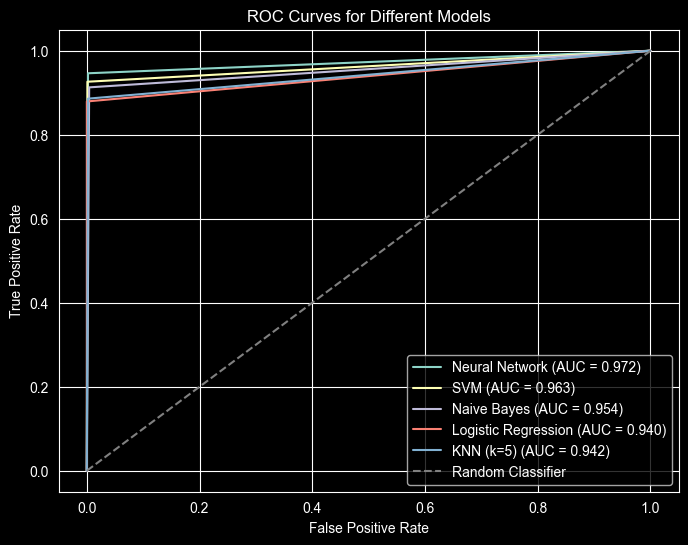

In [42]:
import matplotlib.pyplot as plt
import matplotlib.pyplot as plt

plt.figure(figsize=(8, 6))

for model in results_df.index:
    fpr = results_df.loc[model, "fpr"]   # already a numpy array
    tpr = results_df.loc[model, "tpr"]   # already a numpy array
    roc_auc = results_df.loc[model, "roc_auc"]

    plt.plot(fpr, tpr, label=f"{model} (AUC = {roc_auc:.3f})")

# Add the random classifier baseline
plt.plot([0, 1], [0, 1], color="gray", linestyle="--", label="Random Classifier")



plt.xlabel("False Positive Rate")
plt.ylabel("True Positive Rate")
plt.title("ROC Curves for Different Models")
plt.legend(loc="lower right")
plt.show()


### Conclusion
After  Neural network SVM is the most reliable model of highest AUC and also highest f1 score
